In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [19]:
# write your code here
import sqlite3
import csv

query = ("SELECT r_order.datetime, product.price, product.name, item.quantity "
         "FROM restaurant_orderitem AS item "
         "JOIN restaurant_order AS r_order ON item.order_id = r_order.id "
         "JOIN restaurant_product AS product ON item.product_id = product.id")
with sqlite3.connect("../db.sqlite3") as conn:
    cursor = conn.cursor()
    cursor.execute(query)
    with open("restaurant_orderitems.csv", "w", newline="", encoding="utf-8") as file:
        headers = [data[0] for data in cursor.description]
        writer = csv.writer(file)
        writer.writerow(headers)
        writer.writerows(cursor.fetchall())
df = pd.read_csv("restaurant_orderitems.csv")df

,datetime,price,name,quantity
0,2019-08-03 20:25:00,0.80,Plain Papadum,2
1,2019-08-03 20:25:00,12.95,King Prawn Balti,1
2,2019-08-03 20:25:00,2.95,Garlic Naan,1
3,2019-08-03 20:25:00,3.95,Mushroom Rice,1
4,2019-08-03 20:25:00,8.95,Paneer Tikka Masala,1
...,...,...,...,...
74813,2016-05-18 18:53:00,17.95,House Red wine 75cl,2
74814,2016-05-14 19:28:00,17.95,House Red wine 75cl,2
74815,2016-05-10 13:18:00,17.95,House Red wine 75cl,2
74816,2016-04-07 19:04:00,17.95,House white wine 75cl,1


# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

<Axes: >

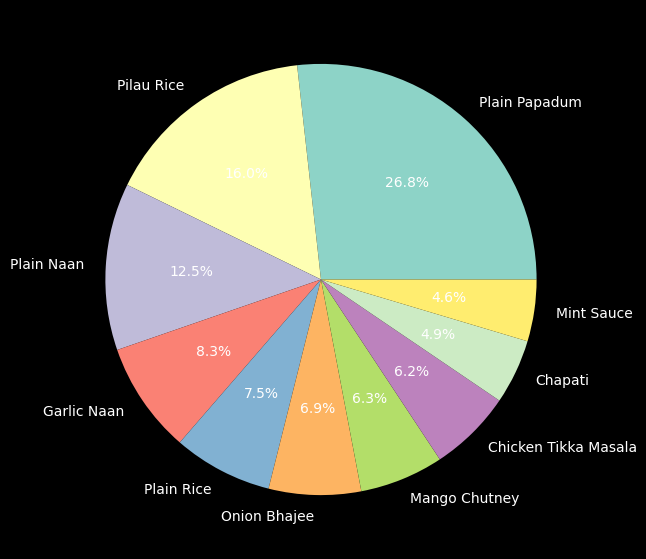

In [20]:
# write your code here
top_10_by_quantity = df.groupby("name")["quantity"].sum().sort_values(ascending=False).head(10)
top_10_by_quantity.plot.pie(autopct="%1.1f%%", figsize=(7,7))

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

<Axes: >

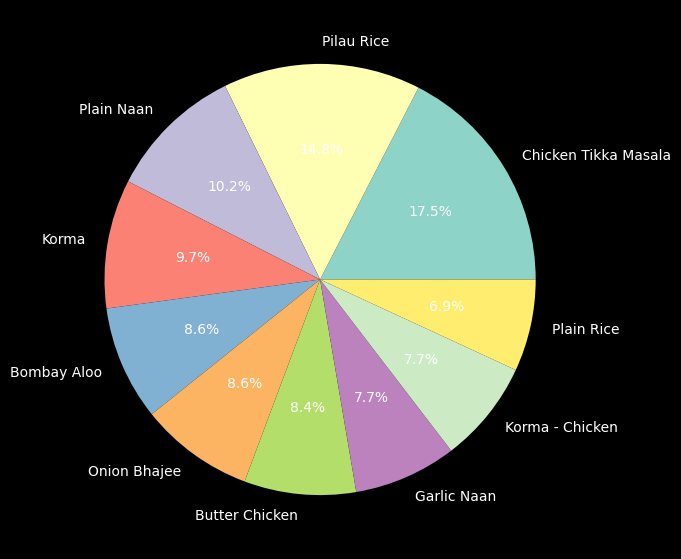

In [15]:
# write your code here
df["Item Price"] = df["price"] * df["quantity"]
top_10_by_item_price = df.groupby("name")["Item Price"].sum().sort_values(ascending=False).head(10)
top_10_by_item_price.plot.pie(autopct="%1.1f%%", figsize=(7,7))

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

<Axes: title={'center': 'Profit by Order Hour'}, xlabel='Order Hour'>

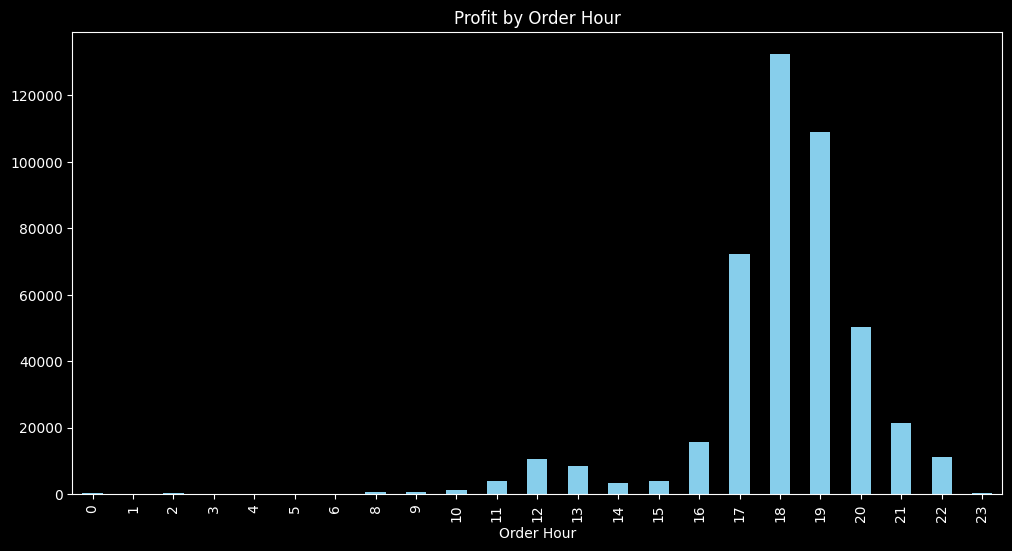

In [16]:
# write your code here
df["Order Hour"] = pd.to_datetime(df["datetime"]).dt.hour
income_by_hour = df.groupby("Order Hour")["Item Price"].sum()
income_by_hour.plot.bar(figsize=(12,6), color="skyblue", title="Profit by Order Hour")


# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

Week day
Monday        40008.30
Tuesday       38145.65
Wednesday     41246.20
Thursday      46021.55
Friday       100339.15
Saturday     112191.65
Sunday        67105.95
Name: Item Price, dtype: float64


<Axes: title={'center': 'Profit by Week day'}, xlabel='Week day'>

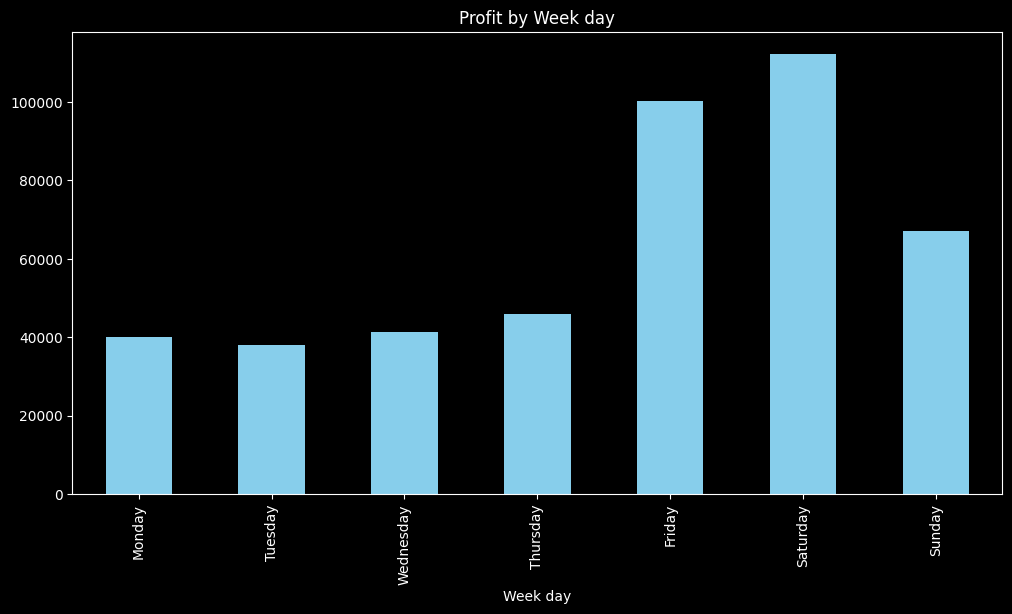

In [17]:
# write your code here
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["Week day"] = pd.to_datetime(df["datetime"]).dt.day_name()
df["Week day"] = pd.Categorical(df["Week day"], categories=weekdays, ordered=True)
income_by_week_day = df.groupby("Week day")["Item Price"].sum()
print(income_by_week_day)
income_by_week_day.plot.bar(figsize=(12,6), color="skyblue", title="Profit by Week day")